# Training Models

Hasta ahora realmente no hemos hecho la tarea de entrenar realmente un modelo en condiciones bueno, hemos solo hecho un par y han sido casi que **Cajas negas** ya que no sabemos lo que pasa por detras y esa es la idea, entender que pasa realmente por detras, para esto, lo que haremos será ver algunos de los modelos mas usuales e interpretables como la regresion lineal y algunas familias y tecnicas de esta misma junto con regresion logistica para temas de clasificacion y *softmax*

## Regresion Lineal

Ya la observamos y tratamos con ella un poco antes, con el ejemplo de **GDP per Capita*, la regresion lineal generalmente la vamos a ver representada algo asi:

$$\hat y = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \dots + \theta_n x_n$$

Otra notacion mas comun que de hecho vemos en el libro es algo asi:

$$h(\mathbf{x}) = \theta^{T}\mathbf{x}$$

con: 
$$ \theta =
\begin{pmatrix}
\theta_{0} \
\theta_{1} \
\vdots \
\theta_{n}
\end{pmatrix},\qquad
\mathbf{x} =
\begin{pmatrix}
1 \
x_{1} \
\vdots \
x_{n}
\end{pmatrix}$$

---

### 1. Definición de la Función de Costo
Buscamos minimizar la suma de los errores al cuadrado ($RSS$). En términos matriciales:

$$J(\beta) = \epsilon^T \epsilon$$

Sustituyendo $\epsilon$:
$$J(\beta) = (y - X\beta)^T (y - X\beta)$$
$$J(\beta) = (y^T - \beta^T X^T) (y - X\beta)$$
$$J(\beta) = y^T y - y^T X \beta - \beta^T X^T y + \beta^T X^T X \beta$$

Como $y^T X \beta$ es un escalar, es igual a su transpuesta ($\beta^T X^T y$), por lo que simplificamos a:
$$J(\beta) = y^T y - 2 \beta^T X^T y + \beta^T X^T X \beta$$

---

### 2. Condición de Primer Orden (Minimización)
Derivamos la función respecto a $\beta$ e igualamos a cero para encontrar el mínimo:

$$\frac{\partial J(\beta)}{\partial \beta} = - 2X^T y + 2X^T X \beta = 0$$

Simplificando (dividiendo entre 2):
$$- X^T y + X^T X \beta = 0$$
$$X^T X \beta = X^T y$$

---

### 3. Estimador MCO ($\hat{\beta}$)
Para despejar $\beta$, multiplicamos por la inversa de $(X^T X)$ por la izquierda:

$$(X^T X)^{-1} X^T X \beta = (X^T X)^{-1} X^T y$$

Finalmente, el estimador es:
$$\hat{\beta} = (X^T X)^{-1} X^T y$$

In [1]:
from ucimlrepo import fetch_ucirepo 

real_estate = fetch_ucirepo(id=477) 
X = real_estate.data.features 
y = real_estate.data.targets 

In [2]:
X

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude
0,2012.917,32.0,84.87882,10,24.98298,121.54024
1,2012.917,19.5,306.59470,9,24.98034,121.53951
2,2013.583,13.3,561.98450,5,24.98746,121.54391
3,2013.500,13.3,561.98450,5,24.98746,121.54391
4,2012.833,5.0,390.56840,5,24.97937,121.54245
...,...,...,...,...,...,...
409,2013.000,13.7,4082.01500,0,24.94155,121.50381
410,2012.667,5.6,90.45606,9,24.97433,121.54310
411,2013.250,18.8,390.96960,7,24.97923,121.53986
412,2013.000,8.1,104.81010,5,24.96674,121.54067


In [3]:
y

,Y house price of unit area
0,37.9
1,42.2
2,47.3
3,54.8
4,43.1
...,...
409,15.4
410,50.0
411,40.6
412,52.5


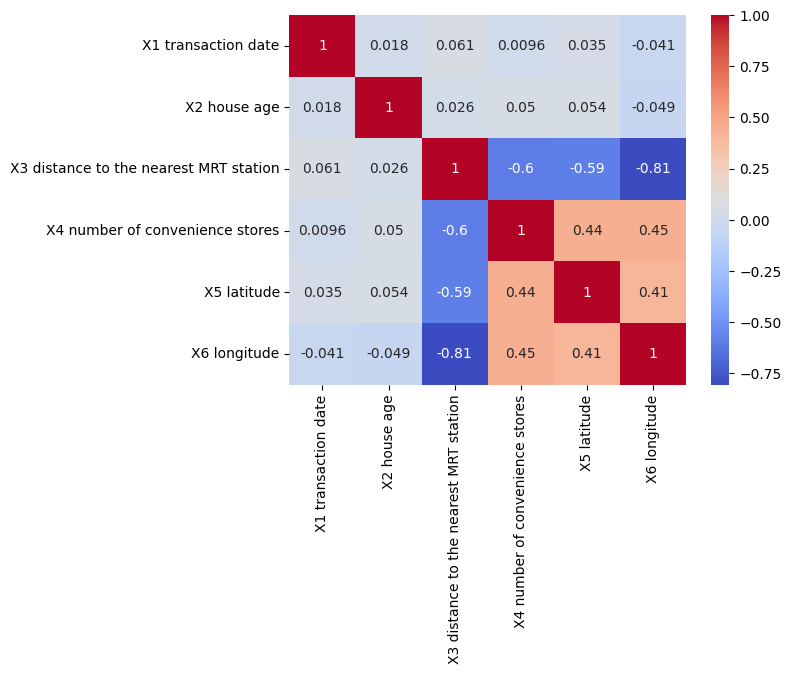

In [4]:
corr=X.corr()
import matplotlib.pyplot as plt
import seaborn as sns
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [7]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [8]:
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse}")
print(f"MAE: {mae}")
print(f"R2: {r2}")

MSE: 53.505619124502054
MAE: 5.305355690074041
R2: 0.6810580555095946


Ahora vemos que el *R2* nos dio muy bajo si probablemente hariamos feature engineriing

In [11]:
X = X.drop(columns=["X5 latitude", "X6 longitude"])

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [13]:
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse}")
print(f"MAE: {mae}")
print(f"R2: {r2}")

MSE: 56.11619009787684
MAE: 5.518993955963183
R2: 0.6654966883840048


## KNN (K-Nearest-Neighbors)


K-Nearest Neighbors (K vecinos más cercanos) es un algoritmo de aprendizaje supervisado usado sobre todo para clasificación y también para regresión.

Para clasificar o predecir un punto nuevo, el algoritmo busca los K puntos más cercanos en el espacio de características (según una medida de distancia, típicamente euclidiana).

- Hiperparámetro K: el número de vecinos (K) se elige por validación; K pequeño puede dar mucho ruido, K grande puede suavizar demasiado las fronteras.

- Escalado: es importante normalizar o estandarizar las variables para que la distancia no dependa de la unidad de medida.

- Basado en instancias: guarda (o usa) los datos de entrenamiento y decide en el momento de la predicción.

- No paramétrico: no asume una forma concreta del modelo (no “aprende” parámetros como la regresión lineal).

---

### 1. Dataset de ejemplo
Supongamos que tenemos **5 puntos** en 2 dimensiones y una etiqueta de clase (A o B):
| Punto | \(x_1\) | \(x_2\) | Clase |
|-------|---------|---------|--------|
| P1    | 1       | 2       | A      |
| P2    | 2       | 3       | A      |
| P3    | 3       | 2       | A      |
| P4    | 6       | 6       | B      |
| P5    | 7       | 5       | B      |
Y queremos clasificar un **punto nuevo** \(Q = (4, 4)\).
---
### 2. Distancia a cada punto (a mano)
Usamos la **distancia euclidiana**:
$$
d(P, Q) = \sqrt{(x_1^P - x_1^Q)^2 + (x_2^P - x_2^Q)^2}
$$
- $d(Q, P1) = \sqrt{(4-1)^2 + (4-2)^2} = \sqrt{9+4} = \sqrt{13} \approx 3.61$
- $d(Q, P2) = \sqrt{(4-2)^2 + (4-3)^2} = \sqrt{4+1} = \sqrt{5} \approx 2.24$
- $d(Q, P3) = \sqrt{(4-3)^2 + (4-2)^2} = \sqrt{1+4} = \sqrt{5} \approx 2.24$
- $d(Q, P4) = \sqrt{(4-6)^2 + (4-6)^2} = \sqrt{4+4} = \sqrt{8} \approx 2.83$
- $d(Q, P5) = \sqrt{(4-7)^2 + (4-5)^2} = \sqrt{9+1} = \sqrt{10} \approx 3.16$
---
### 3. Ordenar por distancia (vecinos más cercanos)
| Orden | Punto | Distancia | Clase |
|-------|--------|-----------|--------|
| 1º    | P2     | 2.24      | A      |
| 2º    | P3     | 2.24      | A      |
| 3º    | P4     | 2.83      | B      |
| 4º    | P5     | 3.16      | B      |
| 5º    | P1     | 3.61      | A      |
---
### 4. Elegir K y votar
- **K = 1**: solo el 1º vecino → P2 → **Clase A**
- **K = 2**: P2 y P3 → ambos A → **Clase A**
- **K = 3**: P2, P3, P4 → 2 A, 1 B → mayoría A → **Clase A**
- **K = 4**: P2, P3, P4, P5 → 2 A, 2 B → empate (depende del criterio; a veces se elige la clase del más cercano) → **A** si desempate por cercanía
- **K = 5**: 3 A, 2 B → **Clase A**
Con **K = 3** (valor típico para datasets pequeños), el punto \(Q = (4, 4)\) se clasifica como **A**.
---
### 5. Resumen del algoritmo
1. Calcular la distancia del punto nuevo a **todos** los puntos del entrenamiento.
2. Ordenar por distancia y quedarse con los **K** más cercanos.
3. En clasificación: asignar la **clase que más se repite** entre esos K vecinos (votación por mayoría).
Con un dataset tan pequeño, el resultado depende mucho de K; en la práctica K se elige por validación cruzada.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

data = {
    "x1":    [1, 2, 3, 6, 7],
    "x2":    [2, 3, 2, 6, 5],
    "clase": ["A","A","A","B","B"]
}

data = pd.DataFrame(data)

X = data[["x1","x2"]]
y = data["clase"]

ks = range(1, 6)

for k in ks:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X, y)
    y_pred = knn.predict(np.array([[4, 4]]))
    print(f"K = {k}: {y_pred}")

K = 1: ['A']
K = 2: ['A']
K = 3: ['A']
K = 4: ['A']
K = 5: ['A']


/mnt/c/Users/Pc/Documents/machine-learning/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/mnt/c/Users/Pc/Documents/machine-learning/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/mnt/c/Users/Pc/Documents/machine-learning/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/mnt/c/Users/Pc/Documents/machine-learning/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/mnt/c/Users/Pc/Documents/machine-learning/.venv/lib/python3.12/

----
Ahora usemos datos reales

In [6]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Cargar datos reales
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target).map({0: "setosa", 1: "versicolor", 2: "virginica"})

In [7]:
X

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [8]:
y

0         setosa
1         setosa
2         setosa
3         setosa
4         setosa
         ...    
145    virginica
146    virginica
147    virginica
148    virginica
149    virginica
Length: 150, dtype: str

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

In [10]:
from sklearn.model_selection import RandomizedSearchCV

params = {"n_neighbors": range(1, 10)}
knn = KNeighborsClassifier()
grid = RandomizedSearchCV(knn, params, cv=5)
grid.fit(X_train_sc, y_train)


/mnt/c/Users/Pc/Documents/machine-learning/.venv/lib/python3.12/site-packages/sklearn/model_selection/_search.py:324: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'n_neighbors': range(1, 10)}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intCon

In [11]:
best_model = grid.best_estimator_
best_model

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",8
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [12]:
y_pred = best_model.predict(X_test_sc)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      1.00      1.00        11
   virginica       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38

[[15  0  0]
 [ 0 11  0]
 [ 0  0 12]]


## Regresión logística

### 1. ¿Qué es la regresión logística?

La **regresión logística** es un modelo de aprendizaje supervisado para **clasificación** (típicamente binaria). No predice un valor continuo como la regresión lineal, sino la **probabilidad** de que la observación pertenezca a la clase 1 (frente a la clase 0). Es un modelo lineal generalizado: la combinación lineal de las variables se pasa por una función no lineal (la **función sigmoide**) para que la salida esté entre 0 y 1.

---

### 2. Planteamiento matemático

#### 2.1 Variable respuesta

- $y_i \in \{0, 1\}$: etiqueta de la observación $i$ (clase 0 o 1).
- Se modela como una **Bernoulli**: $y_i \sim \text{Ber}(p_i)$, con $p_i = P(y_i = 1 \mid \mathbf{x}_i)$.

#### 2.2 Predictor lineal y probabilidad

Se define un **predictor lineal** (como en regresión lineal):

$$
z_i = \beta_0 + \beta_1 x_{i1} + \beta_2 x_{i2} + \cdots + \beta_p x_{ip} = \boldsymbol{\beta}^T \mathbf{x}_i
$$

(con $\mathbf{x}_i$ que incluye un 1 para el término constante si hace falta).

La probabilidad $p_i$ se define usando la **función sigmoide** (función logística):

$$
\sigma(z) = \frac{1}{1 + e^{-z}} = \frac{e^z}{1 + e^z}
$$

y se toma:

$$
p_i = P(y_i = 1 \mid \mathbf{x}_i) = \sigma(z_i) = \frac{1}{1 + e^{-\boldsymbol{\beta}^T \mathbf{x}_i}}
$$

Así $p_i \in (0, 1)$ y se interpreta como la probabilidad de clase 1.

#### 2.3 De dónde sale la sigmoide: odds y log-odds

Se define la **odds** de la clase 1:

$$
\text{odds} = \frac{p}{1-p}
$$

El modelo asume que el **logaritmo de la odds** (log-odds) es lineal en $\mathbf{x}$:

$$
\log \frac{p}{1-p} = \boldsymbol{\beta}^T \mathbf{x}
$$

Despejando $p$:

$$
\frac{p}{1-p} = e^{\boldsymbol{\beta}^T \mathbf{x}} \Rightarrow p = (1-p)\, e^{\boldsymbol{\beta}^T \mathbf{x}} \Rightarrow p = e^{\boldsymbol{\beta}^T \mathbf{x}} - p\, e^{\boldsymbol{\beta}^T \mathbf{x}}
$$

$$
\Rightarrow p\,(1 + e^{\boldsymbol{\beta}^T \mathbf{x}}) = e^{\boldsymbol{\beta}^T \mathbf{x}} \Rightarrow p = \frac{e^{\boldsymbol{\beta}^T \mathbf{x}}}{1 + e^{\boldsymbol{\beta}^T \mathbf{x}}} = \frac{1}{1 + e^{-\boldsymbol{\beta}^T \mathbf{x}}} = \sigma(\boldsymbol{\beta}^T \mathbf{x})
$$

Ahí aparece la **sigmoide**: es la inversa del log-odds lineal.

---

### 3. Estimación por máxima verosimilitud

#### 3.1 Verosimilitud

Para cada observación $i$, $y_i \sim \text{Ber}(p_i)$ con $p_i = \sigma(\boldsymbol{\beta}^T \mathbf{x}_i)$. La función de masa es:

$$
P(y_i \mid \mathbf{x}_i; \boldsymbol{\beta}) = p_i^{y_i}(1-p_i)^{1-y_i}
$$

Con $n$ observaciones independientes, la **verosimilitud** es:

$$
L(\boldsymbol{\beta}) = \prod_{i=1}^{n} p_i^{y_i}(1-p_i)^{1-y_i}, \qquad p_i = \sigma(\boldsymbol{\beta}^T \mathbf{x}_i)
$$

### 3.2 Log-verosimilitud y función de costo

Se maximiza $L$ o, equivalentemente, el **logaritmo**:

$$
\ell(\boldsymbol{\beta}) = \sum_{i=1}^{n} \Big[ y_i \log p_i + (1-y_i) \log(1-p_i) \Big]
$$

En muchos textos se define el **costo** como el negativo (para minimizar en lugar de maximizar):

$$
J(\boldsymbol{\beta}) = -\ell(\boldsymbol{\beta}) = \sum_{i=1}^{n} \Big[ -y_i \log p_i - (1-y_i) \log(1-p_i) \Big]
$$

Esto es la **entropía cruzada binaria** (binary cross-entropy). Minimizar $J$ es equivalente a maximizar $\ell$.

#### 3.3 Gradiente del costo (resumen)

Se puede demostrar que, con $p_i = \sigma(\boldsymbol{\beta}^T \mathbf{x}_i)$ y usando $\sigma'(z) = \sigma(z)(1-\sigma(z))$:

$$
\frac{\partial J}{\partial \boldsymbol{\beta}} = \sum_{i=1}^{n} (p_i - y_i)\,\mathbf{x}_i
$$

En forma matricial, con $\mathbf{p} = \sigma(X\boldsymbol{\beta})$:

$$
\nabla_{\boldsymbol{\beta}} J = X^T(\mathbf{p} - \mathbf{y})
$$

No hay fórmula cerrada para $\boldsymbol{\beta}$; se usa **descenso por gradiente** (o variantes) para minimizar $J$.

---

### 4. Resumen de fórmulas

| Concepto | Fórmula |
|----------|---------|
| Predictor lineal | $z = \boldsymbol{\beta}^T \mathbf{x}$ |
| Sigmoide | $\sigma(z) = \frac{1}{1+e^{-z}}$ |
| Probabilidad clase 1 | $p = \sigma(\boldsymbol{\beta}^T \mathbf{x})$ |
| Decisión | Si $p \geq 0.5$ se predice 1; si $p < 0.5$ se predice 0 |
| Log-verosimilitud | $\ell = \sum_i \big[ y_i \log p_i + (1-y_i)\log(1-p_i) \big]$ |
| Costo (cross-entropy) | $J = -\ell$ |
| Gradiente | $\nabla J = X^T(\mathbf{p} - \mathbf{y})$ |

---

### 5. Ejemplo a mano con un dataset pequeño

#### 5.1 Dataset inventado

Tres puntos en **una variable** $x$, con etiqueta binaria $y$:

| $i$ | $x_i$ | $y_i$ |
|-----|--------|--------|
| 1   | 1      | 0      |
| 2   | 2      | 0      |
| 3   | 4      | 1      |

Modelo: $z_i = \beta_0 + \beta_1 x_i$, $p_i = \sigma(z_i) = \frac{1}{1+e^{-z_i}}$.

### 5.2 Matriz de diseño y vector de etiquetas

Incluyendo columna de unos para $\beta_0$:

$$
X = \begin{pmatrix} 1 & 1 \\ 1 & 2 \\ 1 & 4 \end{pmatrix}, \qquad \mathbf{y} = \begin{pmatrix} 0 \\ 0 \\ 1 \end{pmatrix}
$$

### 5.3 Un paso “a mano” con coeficientes elegidos

Tomamos **valores iniciales** $\beta_0 = -2$, $\beta_1 = 1$ (solo para ilustrar).

- **Punto 1:** $z_1 = -2 + 1\cdot 1 = -1$  
  $p_1 = \frac{1}{1+e^{1}} = \frac{1}{1+2.718} \approx 0.269$

- **Punto 2:** $z_2 = -2 + 1\cdot 2 = 0$  
  $p_2 = \frac{1}{1+e^{0}} = \frac{1}{2} = 0.5$

- **Punto 3:** $z_3 = -2 + 1\cdot 4 = 2$  
  $p_3 = \frac{1}{1+e^{-2}} = \frac{e^2}{1+e^2} \approx \frac{7.389}{8.389} \approx 0.881$

Resumen:

| $i$ | $x_i$ | $y_i$ | $z_i$ | $p_i$ |
|-----|--------|--------|--------|--------|
| 1   | 1      | 0      | -1     | 0.269 |
| 2   | 2      | 0      | 0      | 0.500 |
| 3   | 4      | 1      | 2      | 0.881 |

#### 5.4 Predicción (regla de decisión)

- $p_1 = 0.269 < 0.5 \Rightarrow \hat{y}_1 = 0$ (correcto).
- $p_2 = 0.5 \Rightarrow \hat{y}_2 = 1$ (en el umbral; normalmente se toma 1 o 0 según convención; aquí $y_2=0$, error).
- $p_3 = 0.881 \geq 0.5 \Rightarrow \hat{y}_3 = 1$ (correcto).

#### 5.5 Log-verosimilitud (a mano)

$$
\ell = y_1 \log p_1 + (1-y_1)\log(1-p_1) + y_2 \log p_2 + (1-y_2)\log(1-p_2) + y_3 \log p_3 + (1-y_3)\log(1-p_3)
$$

$$
= 0\cdot \log(0.269) + 1\cdot \log(0.731) + 0\cdot \log(0.5) + 1\cdot \log(0.5) + 1\cdot \log(0.881) + 0\cdot \log(0.119)
$$

$$
= \log(0.731) + \log(0.5) + \log(0.881) \approx -0.313 - 0.693 - 0.127 \approx -1.133
$$

El **costo** sería $J = -\ell \approx 1.133$. Con más iteraciones de descenso por gradiente se ajustarían $\beta_0$ y $\beta_1$ para maximizar $\ell$ (minimizar $J$).

### 5.6 Interpretación del modelo

Cuando esté entrenado, la **frontera de decisión** es donde $p = 0.5$, es decir $z = 0$:

$$
\beta_0 + \beta_1 x = 0 \Rightarrow x = -\frac{\beta_0}{\beta_1}
$$

Para nuestros $\beta_0 = -2$, $\beta_1 = 1$: $x = 2$. A la izquierda de $x=2$ se predice más clase 0; a la derecha, más clase 1.

---

#### 6. Resumen

- La regresión logística modela **$P(y=1 \mid \mathbf{x})$** con una combinación lineal pasada por la **sigmoide**.
- La sigmoide sale de asumir que el **log-odds** es lineal en $\mathbf{x}$.
- Se estiman $\boldsymbol{\beta}$ por **máxima verosimilitud**, que equivale a minimizar la **cross-entropy**.
- No hay solución cerrada; se usa **descenso por gradiente** (o métodos tipo Newton).
- Con un dataset pequeño se puede calcular a mano $z_i$, $p_i$, $\ell$ y $J$ para unos $\boldsymbol{\beta}$ fijos, igual que se hizo el ejemplo paso a paso con KNN.

In [14]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression

# Dataset pequeño del ejemplo a mano
X = np.array([[1], [2], [4]])   # una variable x
y = np.array([0, 0, 1])          # clases

# Entrenar regresión logística (sin regularización para comparar con el ejemplo)
model = LogisticRegression(penalty=None, solver='lbfgs', random_state=42)
model.fit(X, y)

# Coeficientes estimados (beta_0 = intercept_, beta_1 = coef_)
beta_0 = model.intercept_[0]
beta_1 = model.coef_[0][0]
print("Coeficientes estimados:")
print(f"  β₀ = {beta_0:.4f},  β₁ = {beta_1:.4f}\n")

# Probabilidades P(y=1 | x) y predicción para cada punto
p = model.predict_proba(X)[:, 1]   # probabilidad de clase 1
y_pred = model.predict(X)

# Tabla como en el markdown
tabla = pd.DataFrame({
    "x": X.ravel(),
    "y_real": y,
    "z = β₀ + β₁·x": beta_0 + beta_1 * X.ravel(),
    "p = σ(z)": np.round(p, 4),
    "ŷ (pred)": y_pred
})
print("Datos y predicciones:")
print(tabla.to_string(index=False))

Coeficientes estimados:
  β₀ = -26.2432,  β₁ = 8.9101

Datos y predicciones:
 x  y_real  z = β₀ + β₁·x  p = σ(z)  ŷ (pred)
 1       0     -17.333108    0.0000         0
 2       0      -8.423022    0.0002         0
 4       1       9.397150    0.9999         1


/mnt/c/Users/Pc/Documents/machine-learning/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
